In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

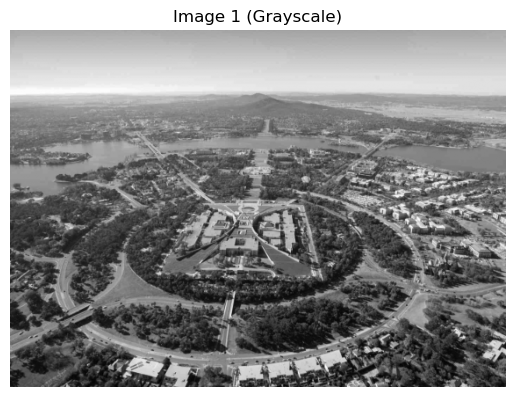

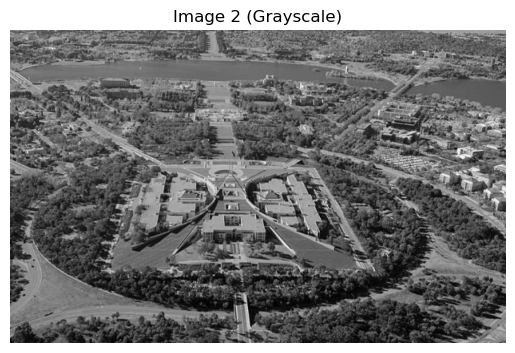

In [2]:
img1 = cv2.imread('canberra1.png')
img2 = cv2.imread('canberra2.png')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.imshow(gray1, cmap='gray')
plt.title("Image 1 (Grayscale)")
plt.axis('off')
plt.show()

plt.imshow(gray2, cmap='gray')
plt.title("Image 2 (Grayscale)")
plt.axis('off')
plt.show()

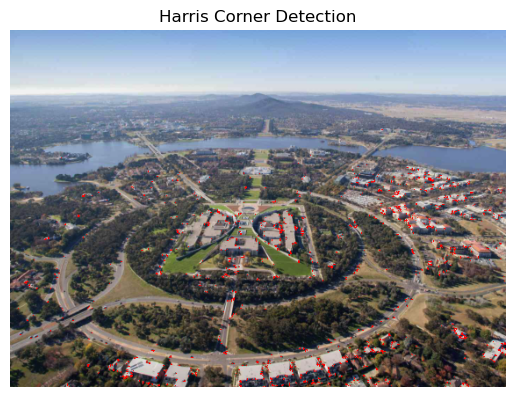

In [3]:
gray1_float = np.float32(gray1)

dst = cv2.cornerHarris(gray1_float, blockSize=2, ksize=3, k=0.04)

img_harris = img1.copy()

img_harris[dst > 0.05 * dst.max()] = [0, 0, 255]

plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title("Harris Corner Detection")
plt.axis('off')
plt.show()

In [4]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("Number of keypoints in Image 1:", len(kp1))
print("Number of keypoints in Image 2:", len(kp2))



Number of keypoints in Image 1: 3238
Number of keypoints in Image 2: 4311


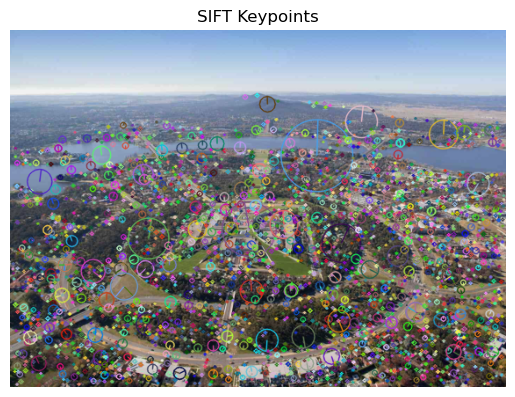

In [5]:
img_sift = cv2.drawKeypoints(
    img1,
    kp1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis('off')
plt.show()

In [6]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)
print("Total matches found:", len(matches))

Total matches found: 1392


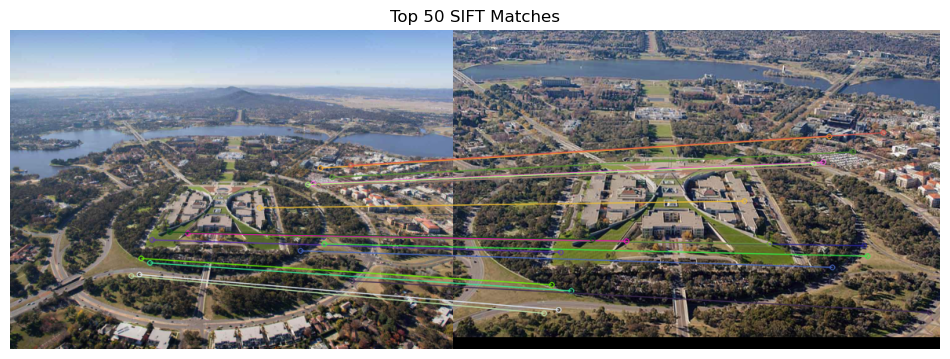

In [8]:
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:20], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Top 50 SIFT Matches")
plt.axis('off')
plt.show() 

In [9]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches after Lowe's ratio test:", len(good_matches))

Good matches after Lowe's ratio test: 237


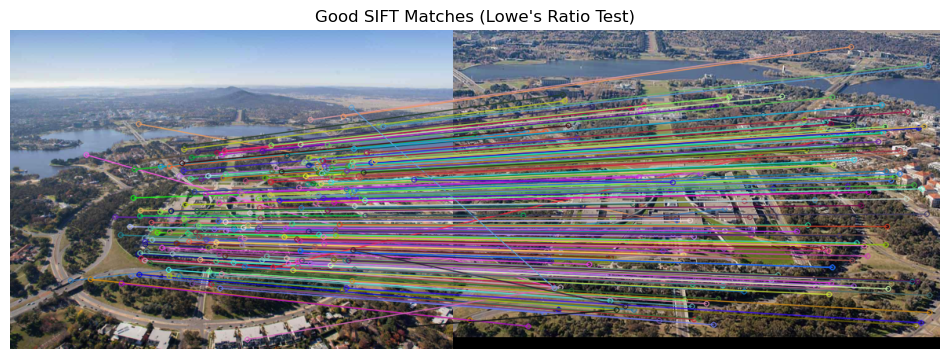

In [14]:
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Good SIFT Matches (Lowe's Ratio Test)")
plt.axis('off')
plt.show()